In [14]:
import nibabel as nib
import os
import torch
import numpy as np

from preprocess_functions import crop_and_resize_square,normalize_image,channel_mask

In [15]:
def recreate_structure(source_folder, target_folder):
    os.makedirs(target_folder, exist_ok=True)
    contents =os.listdir(source_folder)
    for f in contents:
        source_f_path = os.path.join(source_folder,f)
        if os.path.isdir(source_f_path):
            target_f_path = os.path.join(target_folder,f)
            recreate_structure(source_f_path,target_f_path)

In [16]:

source_folder = '../../../data/CardiacUDA/original_data'
target_folder = '../../../data/CardiacUDA/sliced_data'

recreate_structure(source_folder,target_folder)

In [17]:
def anomalies(x,site,patient_num):
    if site == 'Site_G_100' and patient_num == 'patient57-4':
        x[:200] = 0
        x[650:] = 0
        x = x[:, :, :134]

    return x


In [18]:
def preprocess(x,label):
    x = crop_and_resize_square(x)
    if not label:
        x = normalize_image(x)
        x = torch.tensor(x,dtype=torch.float32)
        x = x.unsqueeze(0)
    else:
        x=  x.astype(np.uint8)
        x = channel_mask(x)
        x = torch.tensor(x,dtype=torch.uint8)
    return x

In [19]:

source_folder = '../../../data/CardiacUDA/original_data/train'
target_folder = '../../../data/CardiacUDA/sliced_data/train'
labels_per_frame = 5

for site in os.listdir(source_folder):
    source_site_path = os.path.join(source_folder, site)
    target_site_path = os.path.join(target_folder, site)
    site_files = os.listdir(source_site_path)
    source_patient_data_files = [s for s in site_files if s.endswith('image.nii.gz')]
    for source_data_file in source_patient_data_files:
        patient_num = source_data_file.split('_')[0]

        source_data_file_path = os.path.join(source_site_path, source_data_file)
        
        target_data_folder = os.path.join(target_site_path, patient_num)
        
        patient_data = nib.load(source_data_file_path).get_fdata()
        patient_data = anomalies(patient_data,site=site,patient_num=patient_num)
        for slice_num in range(patient_data.shape[2]):
            slice_folder = os.path.join(target_data_folder, f'slice_{slice_num}')
            os.makedirs(slice_folder,exist_ok=True)

            
            patient_slice = patient_data[:,:,slice_num]
            patient_slice = preprocess(patient_slice,label=False)
            torch.save(patient_slice, os.path.join(slice_folder, 'slice.pt'))   
            print('Saved :',slice_folder)



    source_label_files = [s for s in site_files if s.endswith('label.nii.gz')]
    for source_label in source_label_files:
        source_label_file = os.path.join(source_site_path, source_label)
        patient_num = source_label.split('_')[0]

        target_data_folder = os.path.join(target_site_path, patient_num)
        try:

            label_data = nib.load(source_label_file).get_fdata()
            non_zeros = []
            for i in range(label_data.shape[2]):
                sum = label_data[:,:,i].sum()
                if sum > 0:
                    non_zeros.append((i,sum))


            non_zeros.sort(key=lambda x: x[1], reverse=True)
            valid_non_zeros= non_zeros[:labels_per_frame]
            for slice_num,_ in valid_non_zeros:
                slice_folder = os.path.join(target_data_folder, f'slice_{slice_num}')


                label_slice = label_data[:,:,slice_num]
                label_slice = preprocess(label_slice,label=True)
                torch.save(label_slice, os.path.join(slice_folder, 'label.pt'))

                print('Saved :',slice_folder)
        except:
            print('Error:',source_label_file)



Saved : ../data/sliced_data/train/Site_R_73/patient-108-4/slice_0
Saved : ../data/sliced_data/train/Site_R_73/patient-108-4/slice_1
Saved : ../data/sliced_data/train/Site_R_73/patient-108-4/slice_2
Saved : ../data/sliced_data/train/Site_R_73/patient-108-4/slice_3
Saved : ../data/sliced_data/train/Site_R_73/patient-108-4/slice_4
Saved : ../data/sliced_data/train/Site_R_73/patient-108-4/slice_5
Saved : ../data/sliced_data/train/Site_R_73/patient-108-4/slice_6
Saved : ../data/sliced_data/train/Site_R_73/patient-108-4/slice_7
Saved : ../data/sliced_data/train/Site_R_73/patient-108-4/slice_8
Saved : ../data/sliced_data/train/Site_R_73/patient-108-4/slice_9
Saved : ../data/sliced_data/train/Site_R_73/patient-108-4/slice_10
Saved : ../data/sliced_data/train/Site_R_73/patient-108-4/slice_11
Saved : ../data/sliced_data/train/Site_R_73/patient-108-4/slice_12
Saved : ../data/sliced_data/train/Site_R_73/patient-108-4/slice_13
Saved : ../data/sliced_data/train/Site_R_73/patient-108-4/slice_14
Saved

In [20]:

!dir ../../../data/CardiacUDA/original_data/test/Site_test

normal-23-4_image.nii.gz   patient-35-4_label.nii.gz  patient-60-4_image.nii.gz
normal-23-4_label.nii.gz   patient-39-4_image.nii.gz  patient-60-4_label.nii.gz
normal-27-4_image.nii.gz   patient-39-4_label.nii.gz  patient-64-4_image.nii.gz
normal-27-4_label.nii.gz   patient-44-4_image.nii.gz  patient-64-4_label.nii.gz
patient-17-4_image.nii.gz  patient-44-4_label.nii.gz  patient-67-4_image.nii.gz
patient-17-4_label.nii.gz  patient-5-4_image.nii.gz   patient-67-4_label.nii.gz
patient-35-4_image.nii.gz  patient-5-4_label.nii.gz


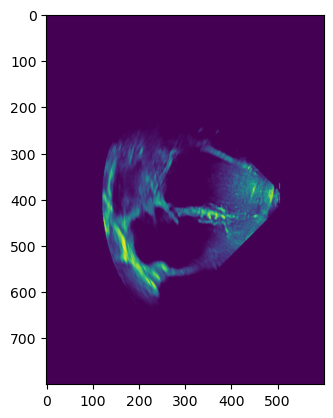

In [21]:
import nibabel as nib
import matplotlib.pyplot as plt
path = '../../../data/CardiacUDA/original_data/test/Site_test/normal-27-4_image.nii.gz'
x = nib.load(path).get_fdata()
x[0:100]=0
x[680:]= 0
x[:,:120]=0
x[:,505:]=0
plt.imshow(x[:,:,0])